How does splitting resolution vary with various parameters?

In [7]:
import igraph as ig
import leidenalg as la

import numpy as np
import scanpy as sc
import pandas as pd
import os
import anndata as ad

from scipy.spatial import ConvexHull
from scipy.spatial import distance
import alphashape

from copy import deepcopy

from scipy.stats import nbinom, poisson, norm, uniform, expon
from scipy import sparse
from scipy.sparse import csr_matrix

import sklearn
from sklearn.decomposition import TruncatedSVD as tSVD
from sklearn.neighbors import kneighbors_graph, NearestNeighbors

from sklearn.metrics import confusion_matrix



import matplotlib.pyplot as plt
import seaborn as sns

import sys

#Import util and processing for tabula_sapiens data from the resolutionTradeoffs github
#sys.path.append('../resolutionTradeoffs/python/')

import util
import dataset_tabula_sapiens
import manuscript_baseline
import dataset_util
import resolution as resol
import manuscript_globalvslocal
import multiprocessing
from multiprocessing import Pool, freeze_support
import json

In [13]:
adata = dataset_tabula_sapiens.tabula_sapiens_heart()

In [14]:
#I edited compute leiden and pipeline to allow custome leiden names
def compute_leiden(s, resolution=1,leiden_name = "leiden"):
    l = util.leiden(s.obsp["connectivities"], resolution=resolution)
    s.obs[leiden_name] = l

    return l


def pipeline(s, k_nn=20, pca_dim=50, resolution=1,leiden_name = "leiden"):
    util.scale(s)
    util.stabilize(s)
    print("creating embedding")
    util.embed(s, pca_dim=pca_dim)
    print("creating graph")
    util.form_graph(s, k_nn=k_nn)
    if resolution is not None:
        print("creating leiden")
        compute_leiden(s, resolution=resolution,leiden_name = leiden_name)
    print("creating umap")
    sc.tl.umap(s)

In [15]:
#Splitting resolutions for cell types for varying knn and pca dims
def parallel_compute_cutoffs(adata, params):
    k_nn, pca_dim = params
    #Copy the adata to avoid issues with parallel processes
    adata = adata.copy()

    #Preprocess the anndata with pca dims and resolution so its ready for cutoff calculation
    pipeline(adata,k_nn=k_nn,
        pca_dim = pca_dim,
        resolution = None,
    )
    #Calculate global splitting resolutions
    df = dataset_util.cutoffs(adata,adata.obs["celltype"], type = "global", min_cluster_size=500,
            k_nn=20, LRI_threshold=0.9, tol=0.02, debug=False)
    
    return dict(zip(list(df['cluster']),list(df['r0'])))

In [3]:
k_nns = [5,10,50,100]
pca_dims = [5,10,50,100]

In [18]:
#List of all combinations of ARI parameters along with the adata
all_params = []
for j, k_nn in enumerate(k_nns):
    for k, pca_dim in enumerate(pca_dims):
        all_params.append((k_nn,pca_dim)) 

In [19]:
multithread_arguments = []
for params in all_params:
    multithread_arguments.append((adata,params))

In [22]:
#Run without multithreading
celltype_cutoffs = []
for multithread_argument in multithread_arguments:
    print(multithread_argument)
    celltype_cutoffs.append(parallel_compute_cutoffs(multithread_argument[0],multithread_argument[1]))

(AnnData object with n_obs × n_vars = 17786 × 1000
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_tissue', 'sample_number', 'organism_ontology_term_id', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tiss

.obsp["connectivities"] have not been computed using umap


creating umap


/storage/users/pruss/conda_envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/storage/users/pruss/conda_envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


constructing cluster adjacency matrice
(AnnData object with n_obs × n_vars = 17786 × 1000
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_tissue', 'sample_number', 'organism_ontology_term_id', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assa

...

constructing cluster adjacency matrice
(AnnData object with n_obs × n_vars = 17786 × 1000
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_tissue', 'sample_number', 'organism_ontology_term_id', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assa

.obsp["connectivities"] have not been computed using umap


creating umap


/storage/users/pruss/conda_envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/storage/users/pruss/conda_envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


constructing cluster adjacency matrice


In [5]:
filename = "../results/celltype_cutoffs_dicts.json"
filename2 = "../results/splitting_res_params.json"

In [ ]:

with open(filename,'w') as f:
    json.dump(celltype_cutoffs,f)


with open(filename2,'w') as f:
    json.dump(all_params,f)

In [9]:
with open(filename, 'r') as file:
    celltype_cutoffs = json.load(file)

with open(filename2, 'r') as file:
    all_params = json.load(file)

In [10]:
celltype_cutoffs

[{'atria': 0.129375,
  'endo': 0.066875,
  'fibr': 0.875,
  'macro': 2.8143750000000005,
  'peri': 0.46875,
  'smus': 0.10687500000000001,
  'vmus': 0.14937499999999998},
 {'atria': 0.129375,
  'endo': 0.051250000000000004,
  'fibr': 1.6943750000000004,
  'macro': 4.764374999999984,
  'peri': 1.5143750000000002,
  'smus': 0.14250000000000002,
  'vmus': 0.02},
 {'atria': 0.1875,
  'endo': 0.02,
  'fibr': 1.0,
  'macro': 2.0,
  'peri': 0.375,
  'smus': 0.16937499999999997,
  'vmus': 0.02},
 {'atria': 0.25875,
  'endo': 0.02,
  'fibr': 1.2068750000000001,
  'macro': 2.0,
  'peri': 0.375,
  'smus': 0.18499999999999997,
  'vmus': 0.02},
 {'atria': 0.129375,
  'endo': 0.066875,
  'fibr': 0.96875,
  'macro': 4.0,
  'peri': 0.484375,
  'smus': 0.066875,
  'vmus': 0.129375},
 {'atria': 0.09375,
  'endo': 0.066875,
  'fibr': 1.544375,
  'macro': 4.855624999999982,
  'peri': 1.6343750000000004,
  'smus': 0.09375,
  'vmus': 0.02},
 {'atria': 0.18499999999999997,
  'endo': 0.02,
  'fibr': 1.0,
  'm

In [11]:
all_params

[[5, 5],
 [5, 10],
 [5, 50],
 [5, 100],
 [10, 5],
 [10, 10],
 [10, 50],
 [10, 100],
 [50, 5],
 [50, 10],
 [50, 50],
 [50, 100],
 [100, 5],
 [100, 10],
 [100, 50],
 [100, 100]]

In [24]:
"""
if __name__ == "__main__":
    with multiprocessing.Pool() as pool:
        # pool.map automatically splits the work across your CPU cores
        celltype_cutoffs = pool.starmap(parallel_compute_cutoffs, multithread_arguments)
    print(celltype_cutoffs)
"""

'\nif __name__ == "__main__":\n    with multiprocessing.Pool() as pool:\n        # pool.map automatically splits the work across your CPU cores\n        celltype_cutoffs = pool.starmap(parallel_compute_cutoffs, multithread_arguments)\n    print(celltype_cutoffs)\n'

In [12]:
celltypes = list(celltype_cutoffs[0].keys())
celltypes

['atria', 'endo', 'fibr', 'macro', 'peri', 'smus', 'vmus']

In [13]:
#Dict of numpy matrices of cutoffs for each cell type 
celltype_heatmap_dict = {}
for celltype in celltypes:
    empty_arr = np.zeros((len(k_nns),len(pca_dims)))

    res_results = pd.DataFrame(empty_arr,index = k_nns,columns = pca_dims)
    
    for params, cutoffs in zip(all_params,celltype_cutoffs):
        k_nn, pca_dim = params
        split_res = cutoffs[celltype]

        res_results.loc[k_nn,pca_dim] = split_res
    celltype_heatmap_dict[celltype] = res_results
    print(res_results)

        


          5         10      50       100
5    0.129375  0.129375  0.1875  0.25875
10   0.129375  0.093750  0.1850  0.21875
50   0.149375  0.109375  0.1875  0.22750
100  0.129375  0.093750  0.2050  0.20750
          5         10    50    100
5    0.066875  0.051250  0.02  0.02
10   0.066875  0.066875  0.02  0.02
50   0.051250  0.046875  0.02  0.02
100  0.066875  0.051250  0.02  0.02
          5         10   50        100
5    0.875000  1.694375  1.0  1.206875
10   0.968750  1.544375  1.0  1.369375
50   0.968750  1.544375  1.0  1.309375
100  0.984375  1.554375  1.0  1.369375
          5         10        50   100
5    2.814375  4.764375  2.000000  2.0
10   4.000000  4.855625  2.000000  2.0
50   2.634375  4.855625  2.366875  2.0
100  2.626875  4.555625  2.434375  2.0
          5         10     50        100
5    0.468750  1.514375  0.375  0.375000
10   0.484375  1.634375  0.370  0.644375
50   0.468750  1.494375  0.350  0.599375
100  0.437500  1.494375  0.410  0.375000
          5        1

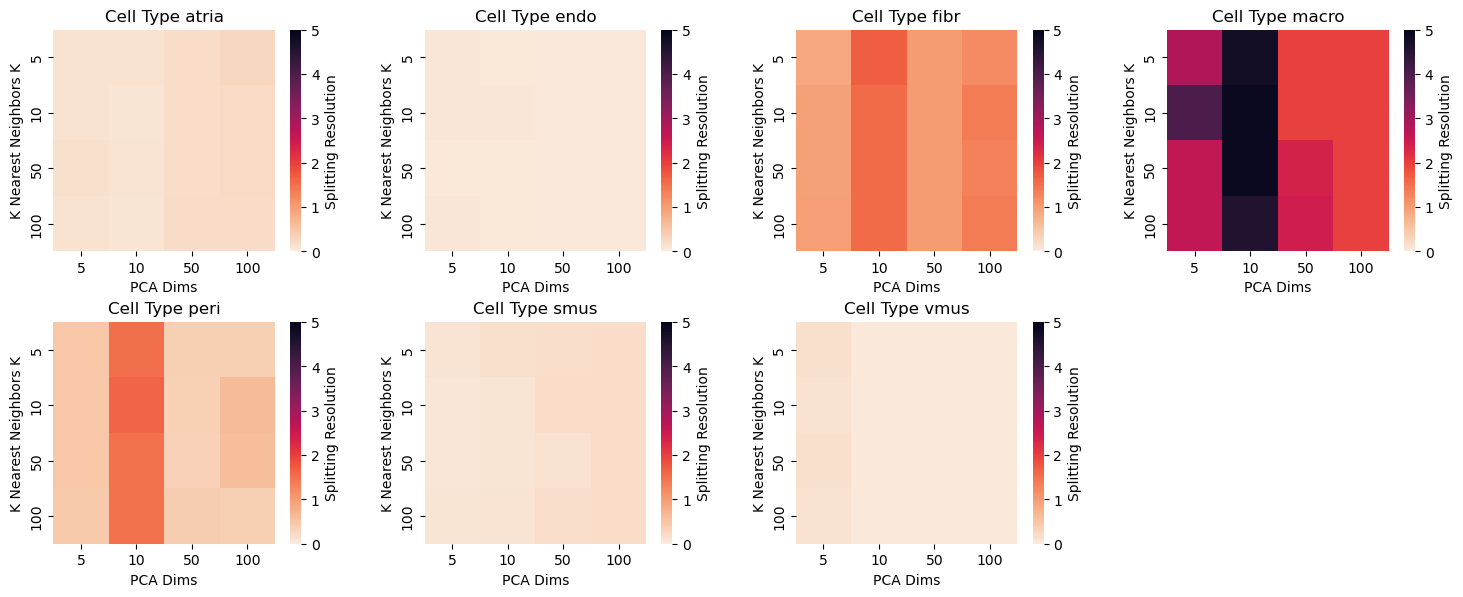

In [14]:
#Make heatmaps

fig, axes = plt.subplots(2,4,figsize = (15,6))

for i, celltype in enumerate(celltypes):
    
    row = i % 4
    col = i // 4
    ax = axes[col][row]
    #ax = axes[i]

    vmax = 5#np.max(celltype_heatmap_dict[celltype].to_numpy())
    vmin = 0#np.min(celltype_heatmap_dict[celltype].to_numpy())
    
    sns.heatmap(celltype_heatmap_dict[celltype],
                yticklabels = k_nns,
                xticklabels = pca_dims,
                vmin = vmin, vmax = vmax,
                cmap = "rocket_r",
                ax = ax,
                cbar_kws={'label': 'Splitting Resolution'})
    ax.set_title(f"Cell Type {celltype}")
    ax.set_ylabel("K Nearest Neighbors K")
    ax.set_xlabel("PCA Dims")
    ax.set_aspect('equal')

axes[1][3].axis('off') 
plt.tight_layout()


plt.show()


In [16]:
best_ks = []
best_pcas = []
for celltype in celltypes:
    matrix = celltype_heatmap_dict[celltype].to_numpy()
    cur_best_param_indices = np.unravel_index(matrix.argmax(), matrix.shape)

    cur_best_k = k_nns[cur_best_param_indices[0]]
    cur_best_pca = pca_dims[cur_best_param_indices[1]]

    best_ks.append(cur_best_k)
    best_pcas.append(cur_best_pca)

Text(0, 0.5, 'Best K Nearest Neighbors K')

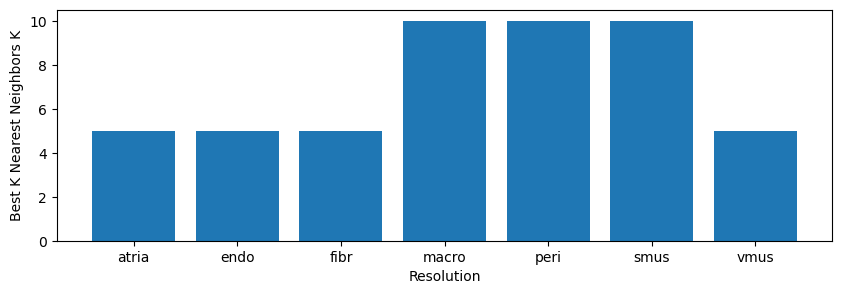

In [17]:
plt.figure(figsize=(10, 3))
plt.bar(celltypes,best_ks)
plt.xlabel("Resolution")
plt.ylabel("Best K Nearest Neighbors K")

Text(0, 0.5, 'Best PCA Dimensions')

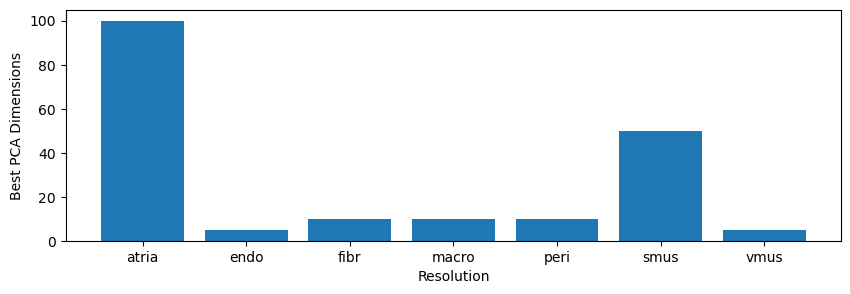

In [18]:
plt.figure(figsize=(10, 3))
plt.bar(celltypes,best_pcas)
plt.xlabel("Resolution")
plt.ylabel("Best PCA Dimensions")